# EM_Demand Phase 1 — Demand Load Index (DLI v0)

Daily national emergency-demand index, 1979–present, with confidence tiers
(1: 2012– VIIRS+MODIS; 2: 2000–2011 MODIS; 3: 1979–1999 polygon burn windows).

**This notebook is orchestration only** — all logic lives in `scripts/` modules
(design decision 8). Heavy steps write parquet checkpoints to `data/derived/`
and are run from the terminal; cells here load checkpoints and display results.
Design doc: `docs/superpowers/specs/2026-07-06-em-demand-phase1-design.md`.

## 0. Config

In [1]:
import sys, subprocess
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import matplotlib.pyplot as plt

from scripts.config import DATA_DERIVED, PATHS, TIER_BOUNDS, COMPONENT_AVAILABILITY
PY = sys.executable
print("tiers:", TIER_BOUNDS)
print("component availability:", COMPONENT_AVAILABILITY)

tiers: {1: ('2012-01-01', None), 2: ('2000-11-01', '2011-12-31'), 3: ('1979-01-01', '2000-10-31')}
component availability: {'drfa': ('2006-03-20', None), 'ffdi': ('1979-01-01', '2023-12-31'), 'tfb_vic': ('1945-01-01', None), 'modis': ('2000-11-01', None), 'viirs_snpp': ('2012-01-01', None), 'tc_besttrack': ('1979-01-01', None), 'fire_polygons': ('1979-01-01', None)}


## 1. Loaders

- FIRMS hotspots: `# USER ACTION REQUIRED` — archive download needs a FIRMS account;
  place country CSVs under `data/raw/firms/` then run the harmonising loader.
- BoM TC best-track: public CSV in `data/raw/bom_tc/IDCKMSTM0S.csv`.
- DRFA + AIDR end-dates, VIC TFB: parsed by `scripts/loaders/`.
- DEA hotspots (cross-validation): `# USER ACTION REQUIRED` — export into `data/raw/dea_hotspots/` (pending).

In [2]:
hs = pd.read_parquet(DATA_DERIVED / "hotspots_firms.parquet", columns=["datetime_utc", "sensor"])
print(f"{len(hs):,} hotspots, {hs.datetime_utc.min():%Y-%m-%d} -> {hs.datetime_utc.max():%Y-%m-%d}")
del hs

23,942,862 hotspots, 2000-11-01 -> 2026-07-06


## 2. Hotspot → fire association

Terminal (heavy, ~3 min): `python3 scripts/run_fire_association.py && python3 scripts/run_satellite_clusters.py`

Polygon-matched hotspots (dwithin 1–2 km + temporal gate) plus ST-DBSCAN
satellite-only clusters for fires missing from the polygon archive.

In [3]:
fd = pd.read_parquet(DATA_DERIVED / "fire_daily.parquet")
sd = pd.read_parquet(DATA_DERIVED / "satellite_fire_daily.parquet")
print(f"polygon-matched: {len(fd):,} fire-days ({fd.fire_id.nunique():,} fires)")
print(f"satellite-only:  {len(sd):,} fire-days ({sd.fire_id.nunique():,} fires)")
del fd, sd

polygon-matched: 123,968 fire-days (37,699 fires)
satellite-only:  1,351,009 fire-days (552,427 fires)


## 3. Daily demand metrics

Terminal: `python3 scripts/run_demand_metrics.py`

Per-region daily metrics: concurrent_burden, ignition_load, growth_load,
frp_load, dispersion_km, n_states_active, unseasonal_hotspots.

71,786 region-days, regions: ['AUS', 'NSW', 'NT', 'QLD', 'SA', 'SEAUS', 'TAS', 'VIC', 'WA']


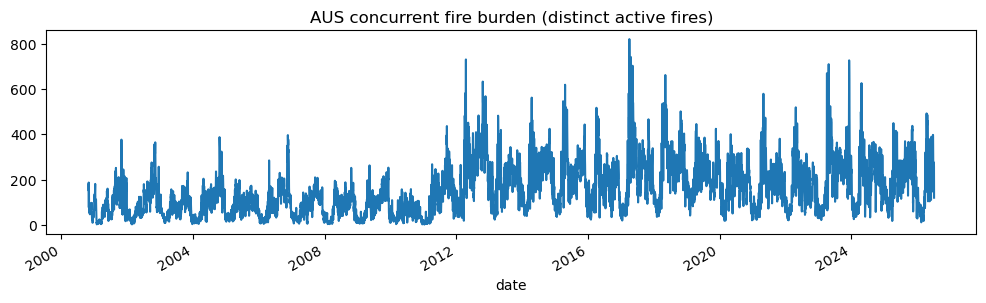

In [4]:
dm = pd.read_parquet(DATA_DERIVED / "demand_metrics_daily.parquet")
print(f"{len(dm):,} region-days, regions: {sorted(dm.region.unique())}")
aus = dm[dm.region == "AUS"].set_index("date")
aus["concurrent_burden"].plot(figsize=(12, 3), title="AUS concurrent fire burden (distinct active fires)")
plt.show()

## 4. DRFA daily activation panel

Daily counts of active disaster-recovery declarations: n_active_events,
n_lga_active (LGA footprint), jurisdictions, hazard flags. Available 2006-03-20 →.

       n_active_events  n_lga_active
count           7305.0        7305.0
mean               1.6          14.9
std                2.1          24.3
min                0.0           0.0
25%                0.0           0.0
50%                1.0           3.0
75%                2.0          19.0
max               12.0         135.0


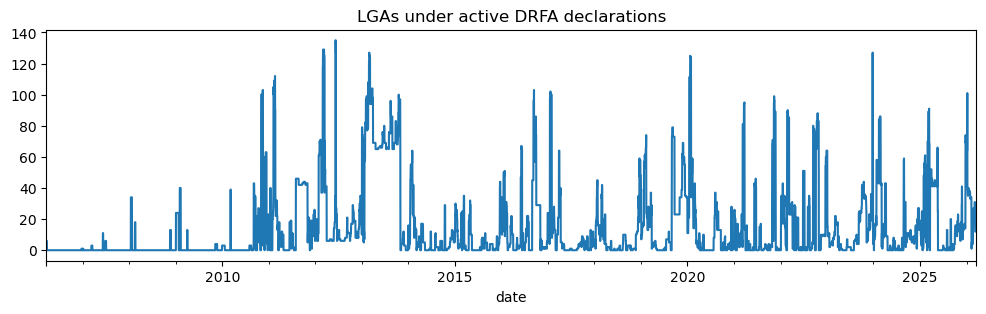

In [5]:
drfa = pd.read_parquet(DATA_DERIVED / "drfa_daily_panel.parquet").set_index("date")
print(drfa[["n_active_events", "n_lga_active"]].describe().round(1))
drfa["n_lga_active"].plot(figsize=(12, 3), title="LGAs under active DRFA declarations")
plt.show()

## 5. DLI v0 + known-event validation

Components percentile-ranked within (tier, calendar month), folded into hazard
subindices (fire / tc / drfa / tfb), DLI = mean of available subindices.
Runs in ~5 s — executed here directly. Every benchmark event must sit in the
upper tail of its tier.

In [6]:
print(subprocess.run([PY, "scripts/run_dli.py"], capture_output=True, text=True).stdout)

inputs loaded (1s)
panel: 17354 days 1979-01-01 -> 2026-07-06 (1s)

Benchmark validation (rank = DLI percentile within tier):
  Ash Wednesday              1983-02-16  tier 3  DLI 0.911  pct 0.9967  n_comp 4
  NSW Jan 1994               1994-01-08  tier 3  DLI 0.718  pct 0.9530  n_comp 4
  VIC Dandenongs Jan 1997    1997-01-21  tier 3  DLI 0.885  pct 0.9961  n_comp 4
  Canberra fires 2003        2003-01-18  tier 2  DLI 0.813  pct 0.9961  n_comp 9
  Black Saturday             2009-02-07  tier 2  DLI 0.895  pct 0.9993  n_comp 11
  TC Yasi                    2011-02-02  tier 2  DLI 0.663  pct 0.9291  n_comp 11
  TAS Dunalley 2013          2013-01-04  tier 1  DLI 0.756  pct 0.9872  n_comp 11
  NSW Blue Mtns Oct 2013     2013-10-17  tier 1  DLI 0.638  pct 0.8959  n_comp 11
  TAS fires Jan 2016         2016-01-20  tier 1  DLI 0.531  pct 0.6072  n_comp 11
  QLD Deepwater Nov 2018     2018-11-28  tier 1  DLI 0.561  pct 0.6982  n_comp 11
  Black Summer peak          2020-01-04  tier 1  DLI 0.731

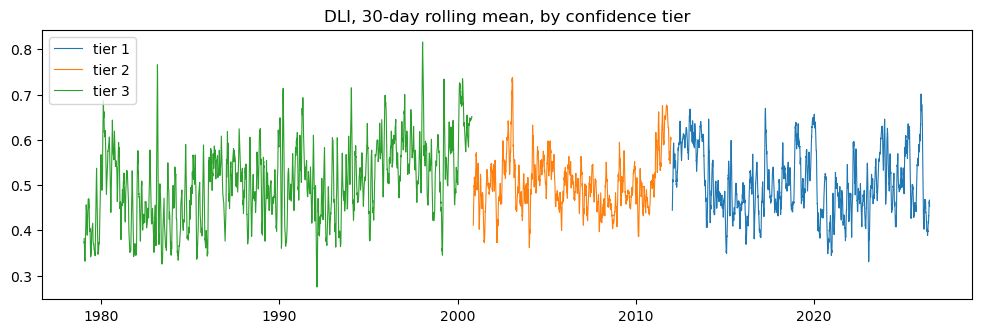

,dli,confidence_tier,sub_fire,sub_tc,sub_drfa,sub_tfb
date,,,,,,
1998-01-25,0.964,3,0.965,0.982,NaN,0.945
1998-01-15,0.963,3,0.987,0.957,NaN,0.945
1998-01-16,0.963,3,0.987,0.957,NaN,0.945
1983-02-25,0.956,3,0.941,0.996,NaN,0.932
1998-01-17,0.948,3,0.991,0.909,NaN,0.945
1998-01-01,0.948,3,0.999,0.900,NaN,0.945
1983-02-23,0.948,3,0.947,0.964,NaN,0.932
1998-01-02,0.947,3,0.997,0.900,NaN,0.945
2000-03-03,0.944,3,0.894,0.988,NaN,0.950


In [7]:
panel = pd.read_parquet(DATA_DERIVED / "demand_daily_panel.parquet").set_index("date")
fig, ax = plt.subplots(figsize=(12, 3.5))
for tier, seg in panel.groupby("confidence_tier"):
    ax.plot(seg.index, seg["dli"].rolling(30, center=True).mean(), lw=0.8, label=f"tier {tier}")
ax.set_title("DLI, 30-day rolling mean, by confidence tier")
ax.legend()
plt.show()
panel.sort_values("dli", ascending=False).head(10)[
    ["dli", "confidence_tier", "sub_fire", "sub_tc", "sub_drfa", "sub_tfb"]].round(3)

## 6. Exports for R (`data/export/`)

In [8]:
print(subprocess.run([PY, "scripts/run_exports.py"], capture_output=True, text=True).stdout)

  demand_daily_panel.csv: 17354 rows
  dli_components_long.csv: 208248 rows
  demand_metrics_daily.csv: 71786 rows
  dli_top50_days.csv: 150 rows
done



## 7. Phase 2–4 stubs

- `scripts/phase2_attribution/` — SWT relative-risk attribution + weather-object composites (Gadi: `gadi/phase2_objects.pbs`)
- `scripts/phase3_compounding/` — compound/sequential demand episodes, recovery gaps
- `scripts/phase4_capacity/` — demand vs capacity exceedance (capacity data not yet secured)

All raise `NotImplementedError`; docstrings define the planned interfaces.